# CARGA DE DATOS Y ANÁLISIS EXPLORATORIO
---

### Clasificación de galaxias según su morfología

#### Integrantes
- `Crespo Neri, Diego Ubaldo` (`ubaldo.crespo@iteso.mx`)
- `Garibay Zepeda, Julio Andrés` (`julio.garibay@iteso.mx`)
- `Vázquez Sandoval, Isaac Ernesto` (`isaac.vazquez@iteso.mx`)

---

### Bibliotecas

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from skimage import io

In [2]:
# Swag
style = "/home/toutl/code/.machine.mplstyle"
if os.path.exists(style):
    plt.style.use(style)

---

### **Carga de datos:**

Los datos que se utilizarán deben estar contenidos en `/data/classification/original/` y consisten en:

- Una colección de imágenes de galaxias, `images_gz2` (necesario descargar).
    - Una tabla adjunta a las imágenes que relaciona el ID de cada objeto con el nombre de los archivos; `gz2_filename_mapping.csv`.
    - Un archivo con información explicativa de las imágenes; `gz2_filename_mapping.txt`.
- Una tabla que contiene las clasificaciones morfológicas de las galaxias de Galaxy Zoo 2 `gz2_hart16.csv` (necesaria descargar);
    - Un archivo explicativo para las variables de dicha tabla; `gz2_hart16.txt`.

In [3]:
data_folder = Path("../../data/classification/")
original_folder = data_folder / "original"
processed_folder = data_folder / "processed"

In [4]:
filenames_df = pd.read_csv(
    original_folder / "gz2_filename_mapping.csv",
    header=0,
    usecols=[0, 2],
    names=["obj_id", "image_id"],
)
morph_classes_df = pd.read_csv(
    original_folder / "gz2_hart16.csv",
    header=0,
    usecols=[0, 6],
    names=["obj_id", "class"],
)

In [5]:
display(filenames_df)
display(morph_classes_df)

,obj_id,image_id
0,587722981736120347,1
1,587722981736579107,2
2,587722981741363294,3
3,587722981741363323,4
4,587722981741559888,5
...,...,...
355985,8647475122541625731,355986
355986,8647475122541625762,355987
355987,8647475122541625774,355988
355988,8647475122761762019,355989


,obj_id,class
0,587732591714893851,Sc+t
1,588009368545984617,Sb+t
2,587732484359913515,Ei
3,587741723357282317,Sc+t
4,587738410866966577,Er
...,...,...
239690,587741490371625059,Ec
239691,587731174917669027,Ei(i)
239692,587731512070177108,Ei
239693,587731513145688256,Ei(i)


In [6]:
merged_df = filenames_df.merge(morph_classes_df, how="inner", on="obj_id")
merged_df.info()
display(merged_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239695 entries, 0 to 239694
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   obj_id    239695 non-null  int64 
 1   image_id  239695 non-null  int64 
 2   class     239695 non-null  object
dtypes: int64(2), object(1)
memory usage: 5.5+ MB


,obj_id,image_id,class
0,587722981741363294,3,Sb
1,587722981741363323,4,Sc?l
2,587722981741559888,5,Er
3,587722981741625481,6,Sc1t
4,587722981741625484,7,Sb


In [7]:
all_classes = merged_df["class"].unique()
print("Clases distintas:", len(all_classes))

Clases distintas: 818


In [8]:
# Simplificar cantidad de clases generalizando
class_mapping = {}
simple_classes = set()

for c in all_classes:
    simple = c[0]
    class_mapping[c] = simple
    simple_classes.add(simple)

print(simple_classes)

{'E', 'S', 'A'}


In [9]:
merged_df["class"] = merged_df["class"].replace(class_mapping)
cleaned_df = merged_df.drop(columns=["obj_id"])
display(cleaned_df.head())

,image_id,class
0,3,S
1,4,S
2,5,E
3,6,S
4,7,S


In [10]:
raw_filenames = os.listdir(original_folder / "images_gz2")
image_ids = [filename.split(".")[0] for filename in raw_filenames]

images_ids_df = pd.DataFrame(image_ids, columns=["image_id"]).astype(int)
display(images_ids_df.head())

,image_id
0,86283
1,47694
2,75083
3,45780
4,9145


In [11]:
final_df = cleaned_df.merge(images_ids_df, how="inner")
final_df.to_csv(processed_folder / "galaxy_morphology.csv", index=False)
display(final_df.head())

,image_id,class
0,3,S
1,4,S
2,6,S
3,7,S
4,13,E


---

### **Análisis exploratorio de datos:**

#### 1. Estructura y Metadata

In [12]:
# Objetos donde obtener la información
images_metadata_df = pd.read_csv(processed_folder / "galaxy_morphology.csv")
display(images_metadata_df.head())

,image_id,class
0,3,S
1,4,S
2,6,S
3,7,S
4,13,E


In [13]:
# Creamos funciones que nos permitan acceder a las imágenes
def load_image(file_name):
    return io.imread(original_folder / "images_gz2" / file_name)


def lazy_load_sample(batch_size):
    sample = images_metadata_df.sample(batch_size, replace=False)
    for _, row in sample.iterrows():
        yield load_image(f"{row['image_id']}.jpg")


def load_sample(batch_size):
    return list(lazy_load_sample(batch_size))


def load_batch(file_ids):
    batch = []
    for f_id in file_ids:
        filename = f"{f_id}.jpg"
        batch.append(io.imread(original_folder / "images_gz2" / filename))
    return batch

In [14]:
# La cantidad de imágenes disponibles
print(len(images_metadata_df))

70623


In [15]:
# Obtenemos una muestra de las imágenes (se utilizan como arreglos)
sample_images = load_sample(30)
print(type(sample_images[0]))

<class 'numpy.ndarray'>


In [16]:
# Revisamos las dimensiones de las imágenes
shapes = np.stack([img.shape for img in sample_images])
display(shapes.mean(axis=0))

array([424., 424.,   3.])

Se cuentan con 70,623 imágenes.
- Formato: `.jpg`.
- Diménsiones: 424 x 424 pixeles.
- Número de bandas: 3 (RGB).
- Profundidad de color: 8 bits (valores entre 0 y 255).

##### Ejemplos

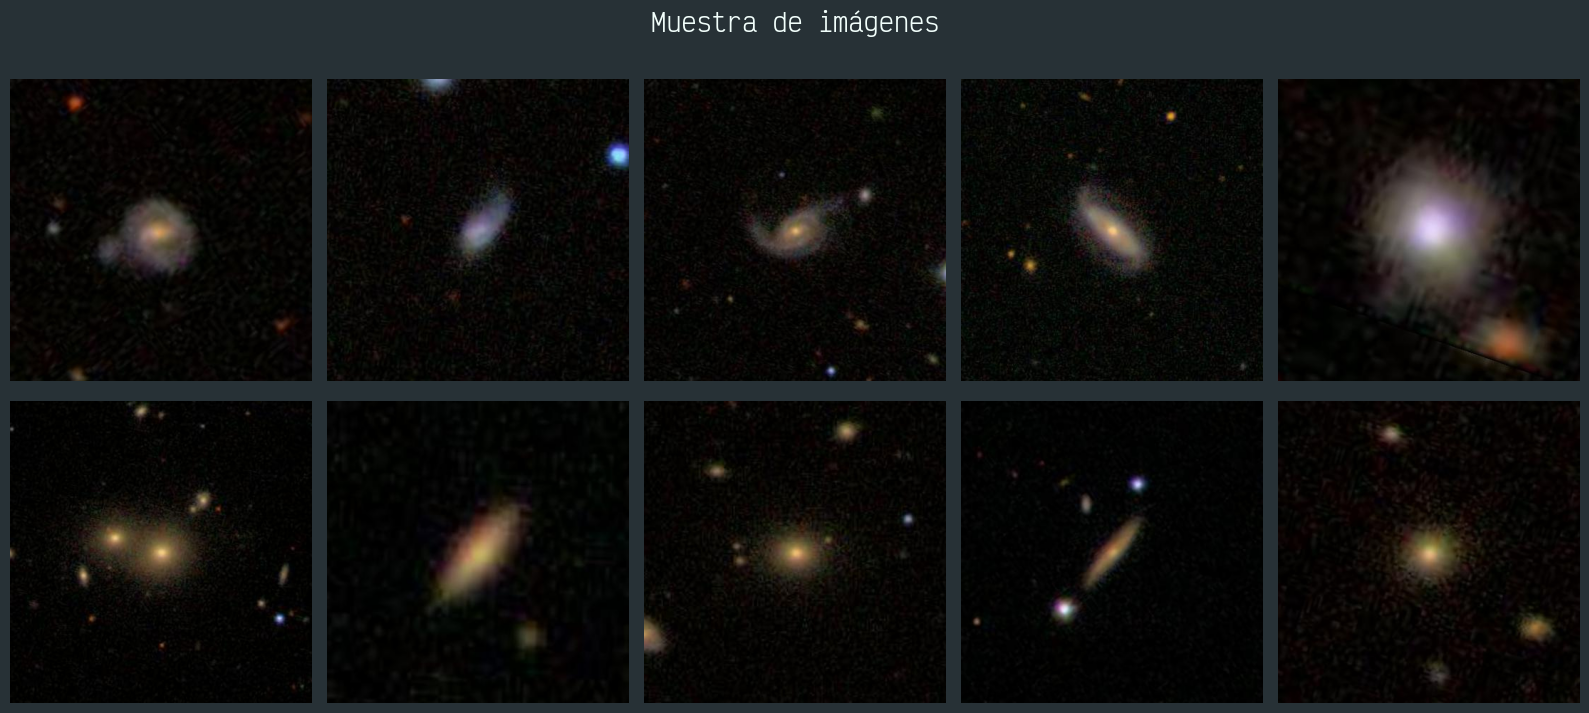

In [17]:
# Algunas imágenes del conjnto de datos
fig, axes = plt.subplots(2, 5, figsize=(16, 7.5), tight_layout=True)

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i])
    ax.axis("off")

fig.suptitle("Muestra de imágenes", fontsize=20)
plt.show()

Observaciones:
- En todas las imágenes se notan los objetos cósmicos centrados.
- Se espera que aquellos centrados sean galaxias.
- Alrededor de los centrales se observan otros objetos, con distintos tamaños y colores.
- Algunas imágenes presentan más zoom que otras, por lo que están más pixeleadas.

Todo esto podría interferir con la identificación, o ser beneficioso.

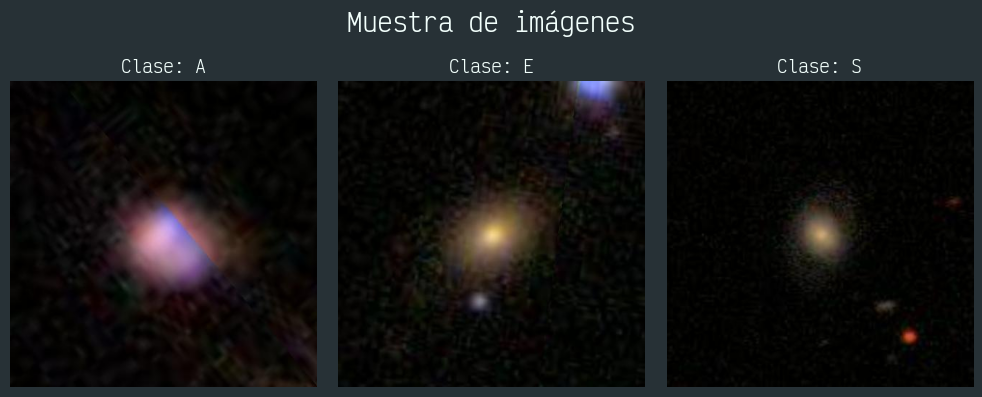

In [18]:
# Algunas imágenes según su clase
class_order = images_metadata_df["class"].unique().tolist()

sample_per_class = (
    images_metadata_df.groupby("class", group_keys=False)
    .sample(1)
    .reset_index(drop=True)
)

sample_images_classes = load_batch(sample_per_class["image_id"].values)

# Graficar
fig, axes = plt.subplots(1, 3, figsize=(10, 4), tight_layout=True)

for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images_classes[i])
    ax.set_title(f"\n\nClase: {sample_per_class.loc[i, 'class']}", fontsize=14)
    ax.axis("off")

fig.suptitle("Muestra de imágenes", fontsize=20)
plt.show()

---

#### 2. Información estadística

##### - Sobre imágenes...

In [19]:
def plot_intensity(image):
    fig, axes = plt.subplots(
        2,
        4,
        figsize=(18, 8),
        gridspec_kw={"width_ratios": [1, 2, 1, 2]},
        constrained_layout=True,
    )

    titles = ["Original", "Rojo", "Verde", "Azul"]
    channels = [None, 0, 1, 2]
    colors = ["white", "C0", "C3", "C4"]

    for idx, (title, ch, color) in enumerate(zip(titles, channels, colors)):
        row = idx // 2
        col = (idx % 2) * 2

        # -- Image
        if ch is None:
            axes[row, col].imshow(image)
            vals = image.mean(axis=2).flatten()
        else:
            axes[row, col].imshow(image[:, :, ch], cmap="gray")
            vals = image[:, :, ch].flatten()

        axes[row, col].set_title(title)
        axes[row, col].axis("off")

        # -- Intensity histogram
        ax_hist = axes[row, col + 1]
        ax_hist.hist(vals, bins=256, log=True, color=color)
        ax_hist.set_title(f"Histograma {title}")
        ax_hist.set_xlabel("Intensidad")
        ax_hist.set_ylabel("Frecuencia")

    plt.show()

Las imágenes del SDSS tienen contrastes muy peculiares, por lo que es útil cuantificar su distribución de intensidades tanto en promedio como por canal. Esto nos ayudará a anticipar qué tipo de preprocesamiento podrían necesitar nuestros modelos.

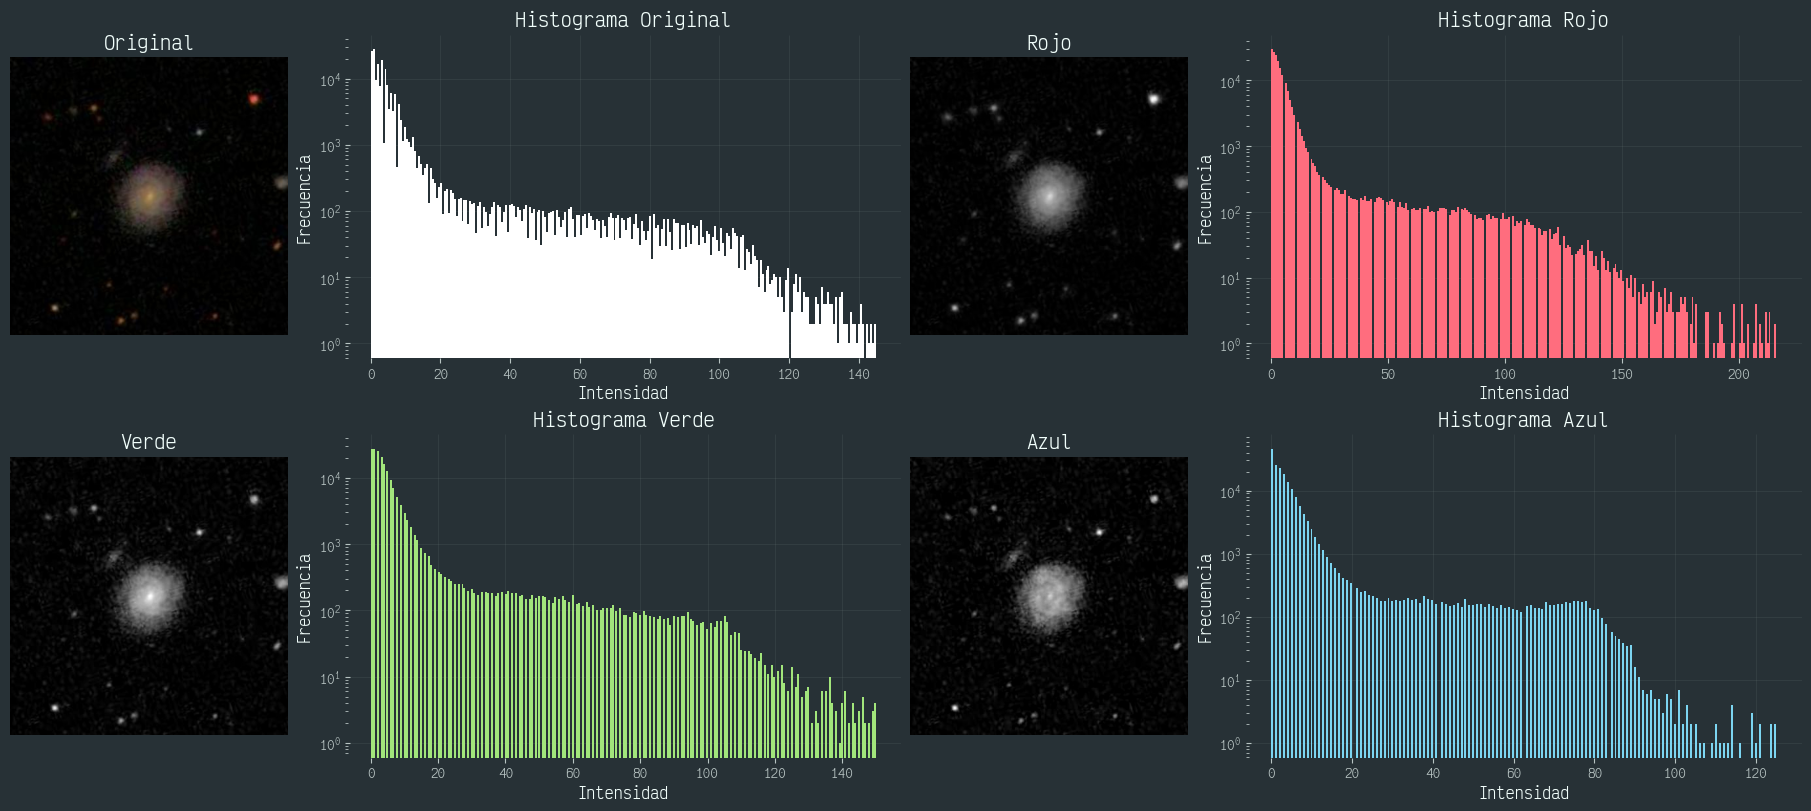

In [20]:
Galaxy = load_sample(1)[0]
plot_intensity(Galaxy)

El histograma de intesidades promedio nos da una idea que la gran mayoría de los colores que aparecen en las imágenes son muy oscuros, hay muchos en tonos medios y muy pocas muy brillantes.

Ademá, parece ser que hay más presencia de tonalidades rojas en la mayorí a de las imágenes. Sin embargo, mientras que hay menor intensidad de azul, en esta banda se aprecian algunos patrones de la forma de las galaxias de mejor manera.

In [21]:
n = 0
mean = 0
M2 = 0

for img in sample_images:
    gray = img.mean(axis=2).flatten()
    data = gray.astype(np.float32).ravel()
    n_i = len(data)
    mean_i = data.mean()
    var_i = data.var()

    # Actualización incremental (Welford’s algorithm)
    delta = mean_i - mean
    total_n = n + n_i
    mean += delta * n_i / total_n
    M2 += var_i * n_i + delta**2 * n * n_i / total_n
    n = total_n

std = np.sqrt(M2 / n)
print("Sample mean intensity:", mean)
print("Sample std intensity:", std)

Sample mean intensity: 10.499191
Sample std intensity: 19.397991


Con intensidades medias de 9.5 y una desviación estándar de 18.5, nos queda más claro que los valores en las imágenes son generalmente muy oscuros en nuestra muestra.

Otras observaciones:
- Debido a la naturaleza de la imágenes no contamos con datos nulos, distribuciones ni datos sesgados.

##### - Sobre etiquetas...

La información que ofrece el proyecto Zoo Galaxy es mucha y muy diversa.

Se utilizarán las etiquetas que fueron clasificadas por la comunidad, en la variable `gz2_class` de `gz2_hart16.csv`. Renombrada como `class` en nuestra carga de datos.

In [22]:
display(images_metadata_df.columns)

Index(['image_id', 'class'], dtype='object')

Se reconocen varias clasificaciónes específicadas en [Galaxy Zoo trees](https://data.galaxyzoo.org/gz_trees/gz_trees.html) (un diagrama guía utilizado por el proyecto para clasificar).

Para este proyecto, se utilizarán las clasificaciones más generales:
- S (Spiral)
- E (Elliptical)
- A (Artifacts/Others)

       count  proportions
class                    
S      41433       0.5867
E      29036       0.4111
A        154       0.0022


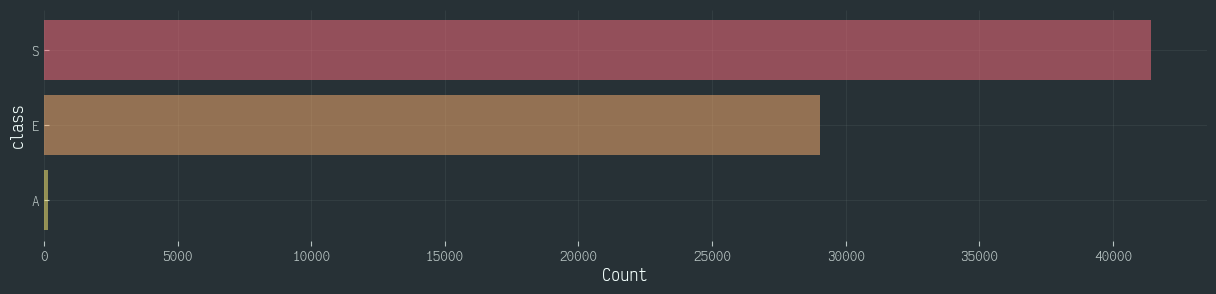

In [23]:
# Revisamos y visualizamos la proporción de clases
print(
    images_metadata_df["class"]
    .value_counts()
    .to_frame()
    .assign(proportions=lambda df: (df["count"] / len(images_metadata_df)))
    .round(4)
)

plt.figure(figsize=(15, 3))
sns.histplot(data=images_metadata_df, y="class", hue="class", shrink=0.8, lw=0, legend=False)
plt.show()

La variable de salida de nuestro conjunto de imágenes se encuentra sumamente imbalanceado, algo que habrá que considerar al momento de seleccionar las métricas del modelo.

---

### **Datos:**

#### Links de descarga:

- [Images (Zenodo)](https://zenodo.org/records/3565489/files/images_gz2.zip?download=1)
- [Classification Table (GalaxyZoo)](https://gz2hart.s3.amazonaws.com/gz2_hart16.csv.gz)

#### Referencias

[1] K. W. Willett et al., “Galaxy Zoo 2: Images from Original Sample,” Zenodo, 2019, DOI: 10.5281/zenodo.3565489.

[2] K. W. Willett et al., “Galaxy Zoo 2: Detailed morphological classifications for 304 122 galaxies from the Sloan Digital Sky Survey,” Mon. Not. R. Astron. Soc., vol. 435, no. 4, pp. 2835–2860, 2013, DOI: 10.1093/mnras/stt1458.

[3] R. E. Hart et al., “Galaxy Zoo: Comparing the demographics of spiral arm number and a new method for correcting redshift bias,” Mon. Not. R. Astron. Soc., vol. 461, no. 4, pp. 3663–3680, 2016, DOI: 10.1093/mnras/stw1588.

[4] “Galaxy Zoo Data Portal – Table 1: Normal-depth sample with new debiasing method,” data.galaxyzoo.org, accessed Sep. 5, 2025.